# Evaluate Rollout From TensorBoard Model on MAT Files

Notebook version of `evaluate_rollout_from_tb_on_mat.py`.


In [1]:
# 1) Setup and configuration
from pathlib import Path
import sys
import math
from dataclasses import asdict
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Resolve project root robustly whether notebook is run from repo root or Experimental_Data.
CWD = Path.cwd().resolve()
if (CWD / "HNN_helper.py").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "HNN_helper.py").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError("Could not locate project root containing HNN_helper.py")

SCRIPT_DIR = PROJECT_ROOT / "Experimental_Data"
for p in (PROJECT_ROOT, SCRIPT_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

import importlib
import HNN_helper as hnn_helper
import methods.vpinn.trainer as vpinn_trainer
from Experimental_Data import export_mat_to_npz_channels as mat_export

hnn_helper = importlib.reload(hnn_helper)
vpinn_trainer = importlib.reload(vpinn_trainer)

PHVIV = hnn_helper.PHVIV
compute_velocity_numpy = hnn_helper.compute_velocity_numpy
parse_config = hnn_helper.parse_config
rollout_model_with_progress = getattr(hnn_helper, "rollout_model_with_progress", hnn_helper.rollout_model)

ScaledForceWrapper = vpinn_trainer.ScaledForceWrapper
_as_diag_param = vpinn_trainer._as_diag_param
_build_force_model = vpinn_trainer._build_force_model
_m_eff_from_model_cfg = vpinn_trainer._m_eff_from_model_cfg
rollout_rk4_with_progress = getattr(vpinn_trainer, "rollout_rk4_with_progress", vpinn_trainer.rollout_rk4)

# Paths and settings
MAT_DIR = PROJECT_ROOT / "Experimental_Data/CrossFlow/CleanedCorrectedSmoothedData"
TB_DIR = PROJECT_ROOT / "Experimental_Data/eval_models/phnnE2_pirate_sym3_0303-124718"
CHECKPOINT_PATH = None  # Optional explicit checkpoint path
OUTPUT_DIR = PROJECT_ROOT / "Experimental_Data/rollout_eval_outputs"
MAT_GLOB = "*.mat"
DATA_VARIABLE = "data"  # set to None for auto-detect
DEVICE = "cpu"  # "cpu" or "cuda"

# Reduced-velocity input mode for rollout:
# "mean" -> constant mean U_r for each file
# "instantaneous" -> per-sample U_r
UR_INPUT_MODE = "mean"

# Plot style
plt.style.use("default")


In [2]:
# 2) Helpers

def _load_state(model: torch.nn.Module, state: dict[str, Any]) -> None:
    if any(k.startswith("_orig_mod.") for k in state):
        state = {k.removeprefix("_orig_mod."): v for k, v in state.items()}
    if any(k.startswith("module.") for k in state):
        state = {k.removeprefix("module."): v for k, v in state.items()}
    model.load_state_dict(state, strict=False)


def _resolve_checkpoint(tb_dir: Path, explicit: Path | None) -> Path:
    if explicit is not None:
        explicit = Path(explicit)
        if not explicit.exists():
            raise FileNotFoundError(f"Checkpoint '{explicit}' not found.")
        return explicit.resolve()

    tb_dir = Path(tb_dir).resolve()
    async_dir = tb_dir / "async_validation"
    if async_dir.exists():
        async_ckpts = sorted(async_dir.glob("epoch_*.pt"))
        if async_ckpts:
            return async_ckpts[-1].resolve()

    run_name = tb_dir.name
    candidate = (PROJECT_ROOT / "models" / f"{run_name}.pt").resolve()
    if candidate.exists():
        return candidate

    local_ckpts = sorted(tb_dir.glob("*.pt"))
    if local_ckpts:
        return local_ckpts[-1].resolve()

    raise FileNotFoundError(
        "Could not resolve checkpoint. Checked:\n"
        f"1) explicit path\n2) {async_dir}\n3) {candidate}\n4) {tb_dir}/*.pt"
    )


def _load_mat_timeseries(mat_path: Path, data_variable: str | None) -> dict[str, np.ndarray]:
    matrix, channel_names = mat_export._load_data_matrix(mat_path, data_variable)
    channels = mat_export._extract_channels(matrix, channel_names)

    time = np.asarray(channels["time"], dtype=float).reshape(-1)
    disp = np.asarray(channels["y"], dtype=float).reshape(-1)
    vel = np.asarray(channels["dy"], dtype=float).reshape(-1)
    ur_inst = np.asarray(channels["U_r_inst"], dtype=float).reshape(-1)

    ur_mode = str(UR_INPUT_MODE).strip().lower()
    if ur_mode == "mean":
        ur_mean = float(np.mean(ur_inst))
        ur = np.full(ur_inst.shape, ur_mean, dtype=float)
    elif ur_mode == "instantaneous":
        ur = ur_inst
    else:
        raise ValueError("UR_INPUT_MODE must be one of: 'mean', 'instantaneous'")

    force = np.asarray(channels["cf_force"], dtype=float).reshape(-1)

    n = int(min(time.size, disp.size, vel.size, ur.size, force.size))
    if n < 3:
        raise ValueError(f"{mat_path.name}: too few aligned samples ({n}).")

    return {
        "time": time[:n],
        "y_true": disp[:n],
        "v_true": vel[:n],
        "ur": ur[:n],
        "force_true": force[:n],
    }


def _align(a: np.ndarray, b: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    n = int(min(a.size, b.size))
    return np.asarray(a[:n], dtype=float), np.asarray(b[:n], dtype=float)


def _error_metrics(pred: np.ndarray, true: np.ndarray, prefix: str) -> dict[str, float]:
    pred_a, true_a = _align(pred, true)
    if pred_a.size == 0:
        return {}
    diff = pred_a - true_a
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    bias = float(np.mean(diff))
    std_true = float(np.std(true_a))
    if std_true <= 0.0:
        std_true = 1.0
    return {
        f"{prefix}_rmse": rmse,
        f"{prefix}_nrmse": rmse / std_true,
        f"{prefix}_mae": mae,
        f"{prefix}_bias": bias,
        f"{prefix}_max_abs": float(np.max(np.abs(diff))),
    }


def _build_phnn_model_for_dt(ckpt: dict[str, Any], cfg: Any, dt: float, device: torch.device):
    model_dict = asdict(cfg.model)
    arch_dict = asdict(cfg.architecture)
    model, derived = PHVIV.from_config(dt=dt, cfg=model_dict, arch_cfg=arch_dict, device=device)
    _load_state(model, ckpt["model_state"])
    model.eval()
    return model, derived


def _build_vpinn_model(ckpt: dict[str, Any], cfg: Any, device: torch.device, d: int = 1):
    vp = dict(cfg.vpinn or {})
    force_representation = str(vp.get("force_representation", "force")).strip().lower()
    use_force_coeff = force_representation == "coefficient"

    m = _as_diag_param(vp.get("m", _m_eff_from_model_cfg(cfg.model)), d, device, "m")
    c = _as_diag_param(vp.get("c", getattr(cfg.model, "damping_c", 1e-4)), d, device, "c")
    k = _as_diag_param(vp.get("k", getattr(cfg.model, "k", 1218.0)), d, device, "k")

    input_dim = 2 * d + 1
    output_dim = d
    base_model = _build_force_model(cfg, input_dim=input_dim, output_dim=output_dim).to(device)

    use_input_scaling = bool(vp.get("use_input_scaling", False))
    if use_input_scaling:
        D_val = float(getattr(cfg.model, "D", 1.0))
        x_scale = D_val if np.isfinite(D_val) and D_val != 0.0 else 1.0
        omega = torch.sqrt(torch.clamp(k / m, min=1e-12))
        v_scale = omega * float(x_scale)
        ur_scale = float(vp.get("ur_scale", 10.0))
        f_scale = 1.0 if use_force_coeff else k * float(x_scale)
        model = ScaledForceWrapper(
            base_model,
            d=d,
            x_scale=x_scale,
            v_scale=v_scale,
            ur_scale=ur_scale,
            f_scale=f_scale,
        )
    else:
        model = base_model

    _load_state(model, ckpt["model_state"])
    model.eval()
    return model, m, c, k, use_force_coeff


def _vpinn_f0_from_ur(cfg: Any, ur_series: np.ndarray) -> float:
    m_eff = float(_m_eff_from_model_cfg(cfg.model))
    k_val = float(getattr(cfg.model, "k", 1218.0))
    D = float(getattr(cfg.model, "D", 0.1))
    rho = float(getattr(cfg.model, "rho", 1000.0))
    if m_eff <= 0.0 or k_val <= 0.0:
        raise ValueError("Invalid model m/k for F0 fallback.")
    fn_hz = math.sqrt(k_val / m_eff) / (2.0 * math.pi)
    ur_finite = np.asarray(ur_series, dtype=float).reshape(-1)
    ur_finite = ur_finite[np.isfinite(ur_finite)]
    if ur_finite.size == 0:
        raise ValueError("Cannot compute F0 fallback: no finite U_r values.")
    U = float(np.mean(ur_finite)) * fn_hz * D
    f0 = 0.5 * rho * D * U * U
    if not np.isfinite(f0) or f0 <= 0.0:
        raise ValueError(f"Invalid F0 fallback value: {f0}")
    return float(f0)


In [3]:
# 3) Load checkpoint + generate rollout/mapping timeseries (top block)
import time

try:
    from tqdm import tqdm
    _HAS_TQDM = True
except Exception:
    _HAS_TQDM = False

# Progress settings for nested rollout bars
ENABLE_PER_ROLLOUT_PROGRESS = True
ROLLOUT_PROGRESS_EVERY = 100  # callback/update frequency in integrator steps

mat_dir = MAT_DIR.resolve()
tb_dir = TB_DIR.resolve()
output_dir = OUTPUT_DIR.resolve()

if not mat_dir.exists():
    raise FileNotFoundError(f"MAT directory '{mat_dir}' not found.")
if not tb_dir.exists():
    raise FileNotFoundError(f"TensorBoard directory '{tb_dir}' not found.")

checkpoint_path = _resolve_checkpoint(tb_dir, CHECKPOINT_PATH)
ckpt = torch.load(checkpoint_path, map_location="cpu")
cfg = parse_config(ckpt.get("config", {}))
method = str(ckpt.get("method", cfg.method)).strip().lower()
device = torch.device(DEVICE if DEVICE == "cuda" and torch.cuda.is_available() else "cpu")

mat_files = sorted(mat_dir.glob(MAT_GLOB))
if not mat_files:
    raise FileNotFoundError(f"No MAT files found in '{mat_dir}' with pattern '{MAT_GLOB}'.")

print(f"Checkpoint: {checkpoint_path}")
print(f"Method: {method}")
print(f"MAT files: {len(mat_files)}")
print(f"U_r input mode: {UR_INPUT_MODE}")
print(f"Device: {device}")
if not _HAS_TQDM:
    print("tqdm not found: using plain text progress.")

entries: list[dict[str, object]] = []
generation_rows: list[dict[str, float | str]] = []

phnn_cache: dict[float, tuple[PHVIV, dict[str, float]]] = {}
vpinn_bundle = None

n_total = len(mat_files)
all_start = time.perf_counter()

if _HAS_TQDM:
    iterator = tqdm(mat_files, total=n_total, desc="Generating timeseries", unit="file")
else:
    iterator = mat_files

for idx, mat_path in enumerate(iterator, start=1):
    file_start = time.perf_counter()
    if _HAS_TQDM:
        iterator.set_postfix_str(mat_path.name)
    else:
        print(f"[{idx}/{n_total}] Processing {mat_path.name} ...")

    ts = _load_mat_timeseries(mat_path, DATA_VARIABLE)
    t = ts["time"]
    y_true = ts["y_true"]
    v_true = ts["v_true"]
    ur = ts["ur"]
    force_true = ts["force_true"]

    dt = float(np.median(np.diff(t)))
    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError(f"{mat_path.name}: invalid dt={dt}")

    if method in {"hnn", "phnn"}:
        if dt not in phnn_cache:
            phnn_cache[dt] = _build_phnn_model_for_dt(ckpt, cfg, dt=dt, device=device)
        model, derived = phnn_cache[dt]

        y_t = torch.from_numpy(y_true).float().to(device)
        v_eval = compute_velocity_numpy(
            y_true,
            dt,
            use_savgol=bool(cfg.smoothing.use_savgol_smoothing),
            savgol_window=int(cfg.smoothing.window_length),
            savgol_polyorder=int(cfg.smoothing.polyorder),
        )
        v_t = torch.from_numpy(v_eval).float().to(device)
        ur_t = torch.from_numpy(ur).float().to(device)

        inner_bar = None
        if _HAS_TQDM and ENABLE_PER_ROLLOUT_PROGRESS:
            inner_bar = tqdm(
                total=int(len(t)),
                desc=f"rollout {mat_path.stem}",
                unit="step",
                leave=False,
            )
            done = [0]

            def _on_rollout_progress(completed: int, total: int) -> None:
                delta = int(completed) - int(done[0])
                if delta > 0:
                    inner_bar.update(delta)
                    done[0] = int(completed)

            progress_cb = _on_rollout_progress
        else:
            progress_cb = None

        try:
            rollout = rollout_model_with_progress(
                model,
                y_t,
                v_t,
                ur_t,
                float(derived["m_eff"]),
                dt,
                t,
                float(derived["D"]),
                float(derived["k"]),
                device,
                progress_callback=progress_cb,
                callback_every=int(ROLLOUT_PROGRESS_EVERY),
            )
        finally:
            if inner_bar is not None:
                inner_bar.close()

        y_roll = np.asarray(rollout["y_norm"], dtype=float) * float(derived["D"])
        force_roll = np.asarray(rollout["force_total"], dtype=float).reshape(-1)

        with torch.no_grad():
            z_true = torch.stack((y_t, v_t * float(derived["m_eff"])), dim=1)
            force_map = model.u_theta(z_true, reduced_velocity=ur_t).squeeze(-1).detach().cpu().numpy()

    elif method == "vpinn":
        if vpinn_bundle is None:
            vpinn_bundle = _build_vpinn_model(ckpt, cfg, device, d=1)
        model, m, c, k, use_force_coeff = vpinn_bundle

        x_t = torch.from_numpy(y_true.reshape(-1, 1)).float().to(device)
        v_t = torch.from_numpy(v_true.reshape(-1, 1)).float().to(device)
        ur_t = torch.from_numpy(ur.reshape(-1, 1)).float().to(device)

        f0 = None
        f0_scalar = None
        if use_force_coeff:
            f0_scalar = _vpinn_f0_from_ur(cfg, ur)
            f0 = torch.tensor([[float(f0_scalar)]], dtype=torch.float32, device=device)

        steps = int(x_t.shape[0] - 1)
        if steps < 1:
            raise ValueError(f"{mat_path.name}: not enough samples for rollout.")

        inner_bar = None
        if _HAS_TQDM and ENABLE_PER_ROLLOUT_PROGRESS:
            inner_bar = tqdm(
                total=int(steps),
                desc=f"rollout {mat_path.stem}",
                unit="step",
                leave=False,
            )
            done = [0]

            def _on_rollout_progress(completed: int, total: int) -> None:
                delta = int(completed) - int(done[0])
                if delta > 0:
                    inner_bar.update(delta)
                    done[0] = int(completed)

            progress_cb = _on_rollout_progress
        else:
            progress_cb = None

        try:
            x_seq, _v_seq, f_seq = rollout_rk4_with_progress(
                model=model,
                x0=x_t[0:1, :],
                v0=v_t[0:1, :],
                ur0=ur_t[0:1, :],
                steps=steps,
                dt=dt,
                m=m,
                c=c,
                k=k,
                f0=f0,
                progress_callback=progress_cb,
                callback_every=int(ROLLOUT_PROGRESS_EVERY),
            )
        finally:
            if inner_bar is not None:
                inner_bar.close()

        y_roll = x_seq[0, :, 0].detach().cpu().numpy()
        force_roll = f_seq[0, :, 0].detach().cpu().numpy()

        with torch.no_grad():
            force_map = model(torch.cat([x_t, v_t, ur_t], dim=-1))[:, 0].detach().cpu().numpy()

        if use_force_coeff and f0_scalar is not None:
            force_roll = force_roll * float(f0_scalar)
            force_map = force_map * float(f0_scalar)

    else:
        raise ValueError(f"Unsupported checkpoint method '{method}'.")

    entries.append(
        {
            "label": mat_path.stem,
            "time": np.asarray(t, dtype=float),
            "y_true": np.asarray(y_true, dtype=float),
            "y_roll": np.asarray(y_roll, dtype=float),
            "force_true": np.asarray(force_true, dtype=float),
            "force_roll": np.asarray(force_roll, dtype=float),
            "force_map": np.asarray(force_map, dtype=float),
        }
    )

    file_elapsed = time.perf_counter() - file_start
    generation_rows.append(
        {
            "file": mat_path.name,
            "samples": int(len(t)),
            "dt_s": float(dt),
            "U_r_mean": float(np.mean(ur)),
            "file_seconds": float(file_elapsed),
        }
    )

    elapsed = time.perf_counter() - all_start
    eta = (elapsed / idx) * (n_total - idx)
    if _HAS_TQDM:
        iterator.set_postfix(
            file=mat_path.name,
            n=int(len(t)),
            dt=f"{dt:.4g}",
            eta_min=f"{eta/60:.1f}",
        )
    else:
        print(
            f"[{idx}/{n_total}] done {mat_path.name} | samples={len(t)}, dt={dt:.6g}s | "
            f"file={file_elapsed:.1f}s, elapsed={elapsed/60:.1f}m, ETA={eta/60:.1f}m"
        )

if _HAS_TQDM:
    iterator.close()

generation_df = pd.DataFrame(generation_rows)
total_elapsed = time.perf_counter() - all_start
print(f"Finished generation for {len(entries)} files in {total_elapsed/60:.2f} min.")
display(generation_df)


Checkpoint: /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/eval_models/phnnE2_pirate_sym3_0303-124718/async_validation/epoch_001560.pt
Method: hnn
MAT files: 10
U_r input mode: mean
Device: cpu


Generating timeseries:  10%|█         | 1/10 [05:53<52:57, 353.03s/file, test3004_corrected.mat]                                       /Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/export_mat_to_npz_channels.py:230: UserWarning: Could not find channel(s) ['Time'] by name for 'time'. Falling back to fixed column 1.
  warnings.warn(
/Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/export_mat_to_npz_channels.py:230: UserWarning: Could not find channel(s) ['Water_Speed'] by name for 'flow speed'. Falling back to fixed column 20.
  warnings.warn(
/Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/export_mat_to_npz_channels.py:230: UserWarning: Could not find channel(s) ['xpos1'] by name for 'CF displacement (xpos1)'. Falling back to fixed column 24.
  warnings.warn(
/Users/kasperslagstad/Desktop/Masterproject/Experimental_Data/export_mat_to_npz_channels.py:230: UserWarning: Could not find channel(s) ['9131_FORCE_2'] by name for 'Fx_chain'. Falling bac

Finished generation for 10 files in 67.62 min.


,file,samples,dt_s,U_r_mean,file_seconds
0,test3003_corrected.mat,126233,0.005,2.934414,353.084281
1,test3004_corrected.mat,188929,0.005,4.073474,518.679345
2,test3005_corrected.mat,153945,0.005,5.783371,420.513361
3,test3006_corrected.mat,253852,0.005,7.700208,695.957934
4,test3008_corrected.mat,131166,0.005,10.005785,358.910529
5,test3010_corrected_part1.mat,106330,0.005,12.136993,288.466734
6,test3010_corrected_part2.mat,137640,0.005,12.036071,375.248700
7,test3011_corrected.mat,143709,0.005,11.696294,376.093406
8,test3012_corrected.mat,97960,0.005,11.642417,227.045239
9,test3014_corrected.mat,195751,0.005,6.792819,443.232522


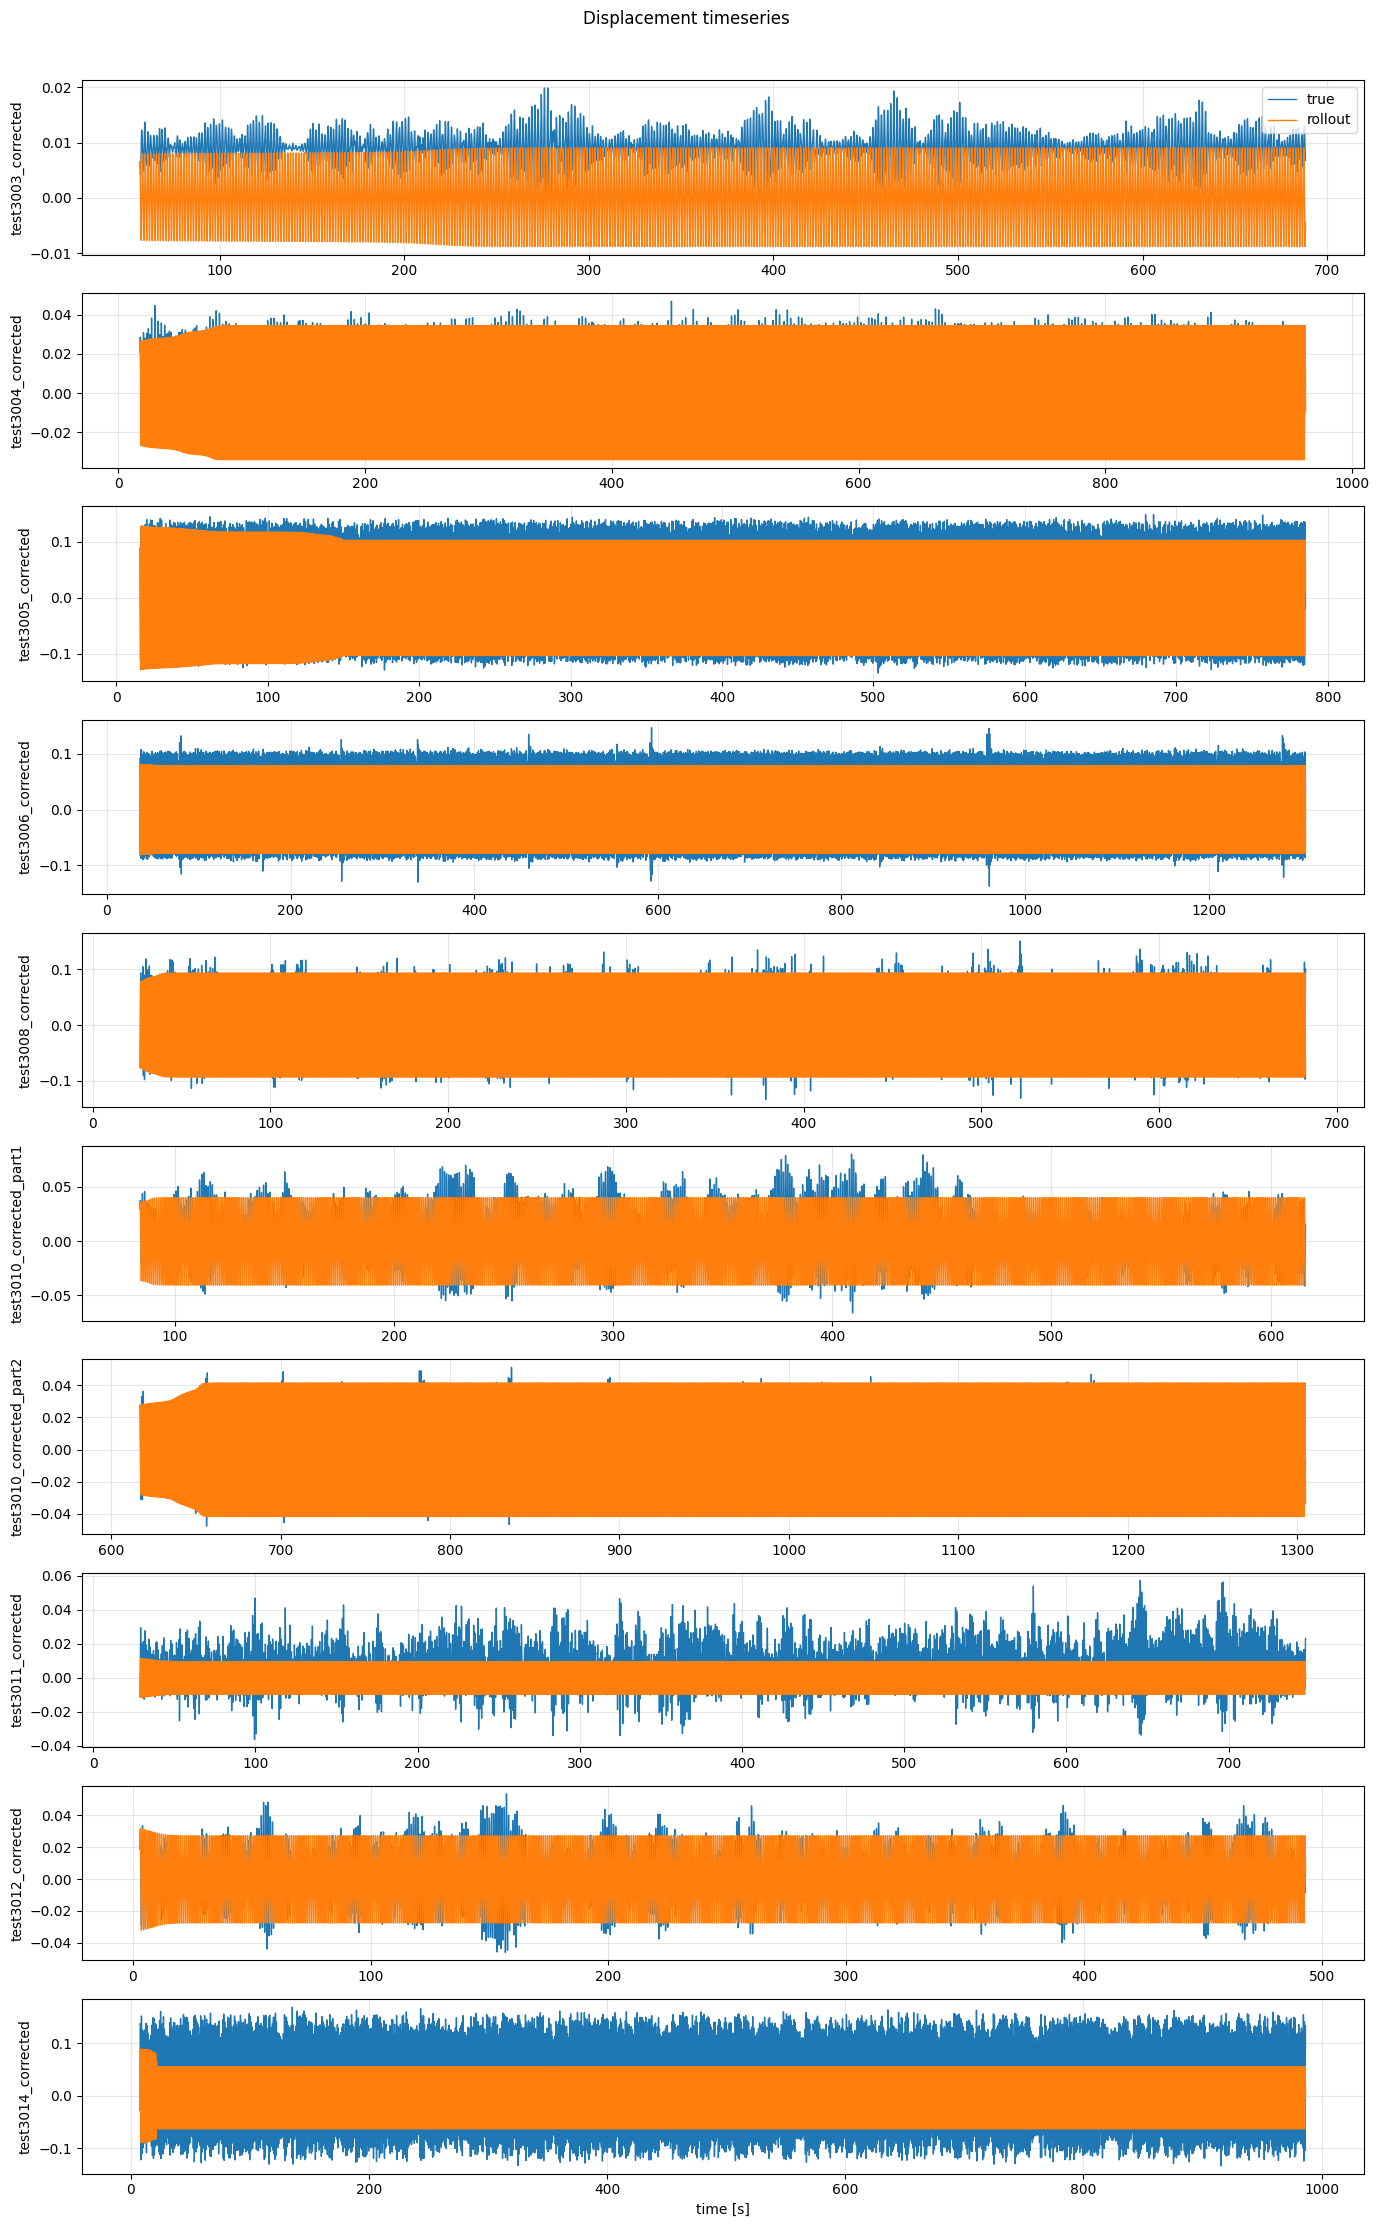

In [4]:
# 4) Plot: displacement timeseries (true vs rollout)
if not entries:
    raise RuntimeError("No entries available. Run block 3 first.")

fig, axes = plt.subplots(len(entries), 1, figsize=(14, max(2.2 * len(entries), 4)), sharex=False)
axes = np.atleast_1d(axes)

for ax, e in zip(axes, entries):
    t = np.asarray(e["time"], dtype=float)
    yt = np.asarray(e["y_true"], dtype=float)
    yr = np.asarray(e["y_roll"], dtype=float)
    n = min(t.size, yt.size, yr.size)
    ax.plot(t[:n], yt[:n], label="true", linewidth=1.0)
    ax.plot(t[:n], yr[:n], label="rollout", linewidth=1.0)
    ax.set_ylabel(e["label"])
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
fig.suptitle("Displacement timeseries", y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
# 5) Plot: displacement error (rollout - true)
if not entries:
    raise RuntimeError("No entries available. Run block 3 first.")

fig, axes = plt.subplots(len(entries), 1, figsize=(14, max(2.2 * len(entries), 4)), sharex=False)
axes = np.atleast_1d(axes)

for ax, e in zip(axes, entries):
    t = np.asarray(e["time"], dtype=float)
    yt = np.asarray(e["y_true"], dtype=float)
    yr = np.asarray(e["y_roll"], dtype=float)
    n = min(t.size, yt.size, yr.size)
    ax.plot(t[:n], yr[:n] - yt[:n], color="tab:red", linewidth=1.0)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel(e["label"])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("time [s]")
fig.suptitle("Displacement error (rollout - true)", y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
# 6) Plot: force timeseries (true, rollout, mapping)
if not entries:
    raise RuntimeError("No entries available. Run block 3 first.")

fig, axes = plt.subplots(len(entries), 1, figsize=(14, max(2.2 * len(entries), 4)), sharex=False)
axes = np.atleast_1d(axes)

for ax, e in zip(axes, entries):
    t = np.asarray(e["time"], dtype=float)
    ft = np.asarray(e["force_true"], dtype=float)
    fr = np.asarray(e["force_roll"], dtype=float)
    fm = np.asarray(e["force_map"], dtype=float)
    n = min(t.size, ft.size, fr.size, fm.size)
    ax.plot(t[:n], ft[:n], label="true force", linewidth=1.0)
    ax.plot(t[:n], fr[:n], label="rollout force", linewidth=1.0)
    ax.plot(t[:n], fm[:n], label="mapping force", linewidth=1.0)
    ax.set_ylabel(e["label"])
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
fig.suptitle("Force timeseries", y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
# 7) Plot: force errors
if not entries:
    raise RuntimeError("No entries available. Run block 3 first.")

fig, axes = plt.subplots(len(entries), 1, figsize=(14, max(2.2 * len(entries), 4)), sharex=False)
axes = np.atleast_1d(axes)

for ax, e in zip(axes, entries):
    t = np.asarray(e["time"], dtype=float)
    ft = np.asarray(e["force_true"], dtype=float)
    fr = np.asarray(e["force_roll"], dtype=float)
    fm = np.asarray(e["force_map"], dtype=float)
    n = min(t.size, ft.size, fr.size, fm.size)
    ax.plot(t[:n], fr[:n] - ft[:n], label="rollout - true", linewidth=1.0)
    ax.plot(t[:n], fm[:n] - ft[:n], label="mapping - true", linewidth=1.0)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel(e["label"])
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
fig.suptitle("Force errors", y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
# 8) Optional: save generation summary CSV
output_dir = OUTPUT_DIR.resolve()
output_dir.mkdir(parents=True, exist_ok=True)
summary_path = output_dir / "generation_summary.csv"
generation_df.to_csv(summary_path, index=False)
print(f"Wrote summary: {summary_path}")
